# 05 — Baseline Model

**Goal:** get one honest number on the board. This is a *baseline*, not a tuned
model — reasonable defaults, no hyperparameter search, no new features.

The point of a baseline is to answer: **does the model beat simply guessing the
most common class?** Notebook 04 showed that on fold 4, always answering "Low"
already scores 69.6% accuracy. Any model has to be measured against that, not
against zero.

What we use, unchanged from earlier notebooks:

- the 16 features from notebook 02 (lags, rolling mean/std, cyclical time)
- the fold definitions from notebook 04 (`cv_folds.csv`)
- the per-fold thresholds from notebook 04 (`cv_fold_thresholds.csv`)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

PROJECT = Path.cwd().parent
PROCESSED = PROJECT / "data" / "processed"

CLASSES = ["Low", "Medium", "High", "Critical"]

features = pd.read_parquet(PROCESSED / "abilene_features.parquet")
fold_days = pd.read_csv(PROCESSED / "cv_folds.csv", parse_dates=["day"])
fold_thresholds = pd.read_csv(PROCESSED / "cv_fold_thresholds.csv")

features["day"] = features["timestamp"].dt.normalize()

pd.set_option("display.width", 200)
print(f"features       : {features.shape[0]:,} rows x {features.shape[1]} cols")
print(f"fold day list  : {len(fold_days):,} rows")
print(f"fold thresholds: {len(fold_thresholds)} (fold, link) pairs")

features       : 1,442,880 rows x 21 cols
fold day list  : 565 rows
fold thresholds: 150 (fold, link) pairs


In [2]:
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#c3c2b7"
INK, MUTED = "#0b0b0b", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "font.size": 9, "legend.frameon": False,
})
print("style set")

style set


## Step 1 — Choosing which columns the model may see

This is the single most important decision in this notebook, and getting it wrong
would produce a meaningless result.

The `congestion` label is calculated **directly from `utilization_pct`** by
comparing it against the thresholds. So if we let the model see
`utilization_pct`, it is not predicting congestion — it is reading the answer.
It would score near 100% and mean nothing.

So `utilization_pct` is **excluded**. The model sees only:

- **6 lags** — what this link was doing 5, 10, 15, 30 minutes and 1 day ago
- **6 rolling** — mean and standard deviation over 30 min, 1 hour, 1 day
- **4 cyclical** — hour of day and day of week, as sine/cosine

Plus one more, which needs justifying:

**`link` identity is included, as a categorical.** Thresholds are per-link, so the
same lag value means different things on different links — 5% utilisation is
Critical on a quiet link and ordinary on a busy one. Without knowing which link it
is looking at, the model cannot resolve that ambiguity. This is not a new
engineered feature; it is a column already in the table.

In [3]:
FEATURES = [c for c in features.columns
            if c not in ("timestamp", "link", "utilization_pct", "congestion", "day")]

print(f"{len(FEATURES)} engineered features:")
for c in FEATURES:
    print("  ", c)
print("\nplus 'link' as a categorical -> "
      f"{len(FEATURES) + 1} model inputs in total")
print("\nEXCLUDED: utilization_pct (the label is computed from it)")

16 engineered features:
   lag_1
   lag_2
   lag_3
   lag_6
   lag_12
   lag_288
   roll_mean_6
   roll_std_6
   roll_mean_12
   roll_std_12
   roll_mean_288
   roll_std_288
   hour_sin
   hour_cos
   dow_sin
   dow_cos

plus 'link' as a categorical -> 17 model inputs in total

EXCLUDED: utilization_pct (the label is computed from it)


## Step 2 — Relabel each fold with its own thresholds

The `congestion` column in the features file was built with **full-series**
thresholds, which notebook 02 flagged as leakage. Notebook 04 produced correct
per-fold thresholds, so we recompute the labels here and ignore that column.

Same rule as always: count how many cut points a value exceeds.

In [4]:
LINK_ORDER = sorted(features["link"].unique())


def build_fold(fold_number):
    """Return X/y for train and test of one fold, labelled with that fold's thresholds."""
    days = fold_days[fold_days.fold == fold_number]
    train_days = set(days[days.part == "train"].day)
    test_days = set(days[days.part == "test"].day)

    train = features[features.day.isin(train_days)]
    test = features[features.day.isin(test_days)]

    cuts = fold_thresholds[fold_thresholds.fold == fold_number].set_index("link")

    def label(block):
        u = block["utilization_pct"]
        return ((u > block["link"].map(cuts["p50"])).astype(int)
                + (u > block["link"].map(cuts["p80"])).astype(int)
                + (u > block["link"].map(cuts["p95"])).astype(int)).to_numpy()

    def design(block):
        X = block[FEATURES].copy()
        X["link"] = pd.Categorical(block["link"], categories=LINK_ORDER)
        return X

    # "Persistence": what class was this link in 5 minutes ago? Labelling lag_1
    # with the same cut points gives a prediction with no model at all.
    persistence = ((test["lag_1"] > test["link"].map(cuts["p50"])).astype(int)
                   + (test["lag_1"] > test["link"].map(cuts["p80"])).astype(int)
                   + (test["lag_1"] > test["link"].map(cuts["p95"])).astype(int))
    # Where lag_1 is missing (start of series / after a gap) fall back to Low,
    # so all three approaches are scored on exactly the same rows.
    persistence = persistence.where(test["lag_1"].notna(), 0).to_numpy()

    return design(train), label(train), design(test), label(test), persistence


X_train, y_train, X_test, y_test, _ = build_fold(1)
print(f"fold 1 -> train {X_train.shape}, test {X_test.shape}")
print("\ntrain class balance:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index()
        .rename(lambda i: CLASSES[i]).mul(100).round(2).to_string())

fold 1 -> train (276480, 17), test (233280, 17)

train class balance:
Low         50.31
Medium      29.68
High        15.00
Critical     5.00


## Step 3 — Handling the class imbalance

Training is roughly 50 / 30 / 15 / 5, so "Critical" is outnumbered ten to one by
"Low". Left alone, the model would learn that predicting Low is usually safe and
would rarely commit to Critical — which is precisely the class we care about.

We use scikit-learn's **`compute_sample_weight("balanced", y)`**, which gives each
row a weight inversely proportional to how common its class is. Rare classes get
heavier weights, so a mistake on a Critical row costs the model more.

Nothing custom — one standard call.

In [5]:
weights = compute_sample_weight("balanced", y_train)

print("weight assigned to each class:")
for code_, name in enumerate(CLASSES):
    mask = y_train == code_
    if mask.any():
        print(f"  {name:<9} {weights[mask][0]:6.3f}   ({mask.sum():,} rows)")
print("\nRarer class -> bigger weight. They multiply out to equal total influence.")

weight assigned to each class:
  Low        0.497   (139,105 rows)
  Medium     0.842   (82,073 rows)
  High       1.667   (41,472 rows)
  Critical   4.998   (13,830 rows)

Rarer class -> bigger weight. They multiply out to equal total influence.


## Step 4 — The model

`XGBClassifier` with ordinary settings. `tree_method="hist"` because the training
sets run to over a million rows; `enable_categorical=True` so the `link` column
can be passed as a category rather than one-hot encoded.

The lag and rolling features contain `NaN` wherever they would have crossed a data
gap (notebook 02). **XGBoost handles missing values natively** — it learns which
way to send them at each split — so no imputation is needed. That is why the NaNs
were kept rather than filled.

No tuning. These are defaults chosen to be reasonable, not searched.

In [6]:
def make_model():
    return XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        tree_method="hist",
        enable_categorical=True,
        objective="multi:softmax",
        num_class=len(CLASSES),
        n_jobs=-1,
        random_state=42,
    )


print(make_model())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_class=4, ...)


## Step 5 — Train and evaluate every fold

We score three things on identical rows:

1. **The model** — XGBoost on the 16 features plus link identity.
2. **Naive (majority class)** — always predict whichever class was most common in
   that fold's *training* data. Training is ~50% Low, so this means always
   answering "Low".
3. **Persistence** — predict whatever class the link was in **5 minutes ago**. No
   model, no training: just label `lag_1` with the same thresholds.

The third one is not something the brief asked for, but it is the comparison that
actually tells us whether the model is earning its keep. Beating "always say Low"
is a low bar; beating "assume nothing changed in five minutes" is the real test
for a smooth time series.

In [7]:
per_class_rows = []
summary_rows = []
confusions = {}

for fold_number in sorted(fold_days.fold.unique()):
    X_train, y_train, X_test, y_test, persistence = build_fold(fold_number)

    model = make_model()
    model.fit(X_train, y_train,
              sample_weight=compute_sample_weight("balanced", y_train))
    predictions = model.predict(X_test)

    # Naive baseline: the most common class in TRAINING, predicted every time.
    majority_class = np.bincount(y_train, minlength=len(CLASSES)).argmax()
    naive = np.full_like(y_test, majority_class)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, predictions, labels=range(len(CLASSES)), zero_division=0)

    for i, name in enumerate(CLASSES):
        per_class_rows.append({
            "fold": fold_number, "class": name,
            "precision": precision[i], "recall": recall[i],
            "f1": f1[i], "support": support[i],
        })

    confusions[fold_number] = confusion_matrix(
        y_test, predictions, labels=range(len(CLASSES)))

    summary_rows.append({
        "fold": fold_number,
        "train_rows": len(y_train), "test_rows": len(y_test),
        "test_critical_%": round((y_test == 3).mean() * 100, 2),
        "accuracy": accuracy_score(y_test, predictions),
        "macro_F1": f1_score(y_test, predictions, average="macro", zero_division=0),
        "naive_accuracy": accuracy_score(y_test, naive),
        "naive_macro_F1": f1_score(y_test, naive, average="macro", zero_division=0),
        "persist_accuracy": accuracy_score(y_test, persistence),
        "persist_macro_F1": f1_score(y_test, persistence, average="macro",
                                     zero_division=0),
        "critical_precision": precision[3],
        "critical_recall": recall[3],
        "critical_F1": f1[3],
    })
    print(f"fold {fold_number} done - "
          f"model {summary_rows[-1]['accuracy']:.3f} acc / "
          f"{summary_rows[-1]['macro_F1']:.3f} macro-F1  |  "
          f"persistence {summary_rows[-1]['persist_accuracy']:.3f} / "
          f"{summary_rows[-1]['persist_macro_F1']:.3f}")

summary = pd.DataFrame(summary_rows)
per_class = pd.DataFrame(per_class_rows)
print("\nall folds trained")

fold 1 done - model 0.888 acc / 0.847 macro-F1  |  persistence 0.906 / 0.879


fold 2 done - model 0.903 acc / 0.801 macro-F1  |  persistence 0.908 / 0.815


fold 3 done - model 0.918 acc / 0.800 macro-F1  |  persistence 0.918 / 0.790


fold 4 done - model 0.892 acc / 0.750 macro-F1  |  persistence 0.890 / 0.750


fold 5 done - model 0.856 acc / 0.835 macro-F1  |  persistence 0.859 / 0.840

all folds trained


## Step 6 — Per-fold detail

In [8]:
for fold_number in summary.fold:
    row = summary[summary.fold == fold_number].iloc[0]
    print("=" * 78)
    print(f"FOLD {fold_number}   test rows {row.test_rows:,}   "
          f"Critical in test: {row['test_critical_%']}%")
    print("=" * 78)

    detail = per_class[per_class.fold == fold_number][
        ["class", "precision", "recall", "f1", "support"]]
    print(detail.round(3).to_string(index=False))

    print(f"\n{'':12}{'model':>10}{'naive (always Low)':>20}{'persistence':>14}")
    print(f"{'accuracy':12}{row.accuracy:>10.4f}{row.naive_accuracy:>20.4f}"
          f"{row.persist_accuracy:>14.4f}")
    print(f"{'macro F1':12}{row.macro_F1:>10.4f}{row.naive_macro_F1:>20.4f}"
          f"{row.persist_macro_F1:>14.4f}")

    print("\nconfusion matrix (rows = actual, columns = predicted):")
    print(pd.DataFrame(confusions[fold_number],
                       index=[f"actual {c}" for c in CLASSES],
                       columns=[f"pred {c}" for c in CLASSES]).to_string())
    print()

FOLD 1   test rows 233,280.0   Critical in test: 6.93%
   class  precision  recall    f1  support
     Low      0.971   0.951 0.961   107258
  Medium      0.866   0.862 0.864    69795
    High      0.780   0.789 0.785    40055
Critical      0.735   0.831 0.780    16172

                 model  naive (always Low)   persistence
accuracy        0.8883              0.4598        0.9059
macro F1        0.8474              0.1575        0.8788

confusion matrix (rows = actual, columns = predicted):
                 pred Low  pred Medium  pred High  pred Critical
actual Low         102002         5149         83             24
actual Medium        2898        60180       6280            437
actual High            69         4007      31601           4378
actual Critical        28          175       2538          13431

FOLD 2   test rows 233,280.0   Critical in test: 2.05%
   class  precision  recall    f1  support
     Low      0.967   0.940 0.954   159207
  Medium      0.816   0.843 0.830  

## Step 7 — All five folds side by side

In [9]:
view = summary[["fold", "test_critical_%", "accuracy", "naive_accuracy",
                "persist_accuracy", "macro_F1", "naive_macro_F1",
                "persist_macro_F1"]]
print("ACCURACY AND MACRO-F1, ALL THREE APPROACHES")
print(view.round(4).to_string(index=False))

print("\n\nCRITICAL CLASS (the one that matters for rerouting)")
print(summary[["fold", "test_critical_%", "critical_precision",
               "critical_recall", "critical_F1"]].round(4).to_string(index=False))

print("\n\nWHAT THE MODEL ADDS")
lift = pd.DataFrame({
    "fold": summary.fold,
    "vs naive (acc)": (summary.accuracy - summary.naive_accuracy).round(4),
    "vs naive (F1)": (summary.macro_F1 - summary.naive_macro_F1).round(4),
    "vs persistence (acc)": (summary.accuracy - summary.persist_accuracy).round(4),
    "vs persistence (F1)": (summary.macro_F1 - summary.persist_macro_F1).round(4),
})
print(lift.to_string(index=False))
print(f"\nmean gain over naive       : "
      f"{lift['vs naive (F1)'].mean():+.4f} macro-F1")
print(f"mean gain over persistence : "
      f"{lift['vs persistence (F1)'].mean():+.4f} macro-F1")

ACCURACY AND MACRO-F1, ALL THREE APPROACHES
 fold  test_critical_%  accuracy  naive_accuracy  persist_accuracy  macro_F1  naive_macro_F1  persist_macro_F1
    1             6.93    0.8883          0.4598            0.9059    0.8474          0.1575            0.8788
    2             2.05    0.9035          0.6825            0.9078    0.8006          0.2028            0.8154
    3             1.70    0.9176          0.7495            0.9178    0.7996          0.2142            0.7904
    4             0.92    0.8918          0.6959            0.8899    0.7500          0.2052            0.7501
    5            10.14    0.8560          0.4767            0.8589    0.8347          0.1614            0.8404


CRITICAL CLASS (the one that matters for rerouting)
 fold  test_critical_%  critical_precision  critical_recall  critical_F1
    1             6.93              0.7351           0.8305       0.7799
    2             2.05              0.6965           0.7818       0.7367
    3            

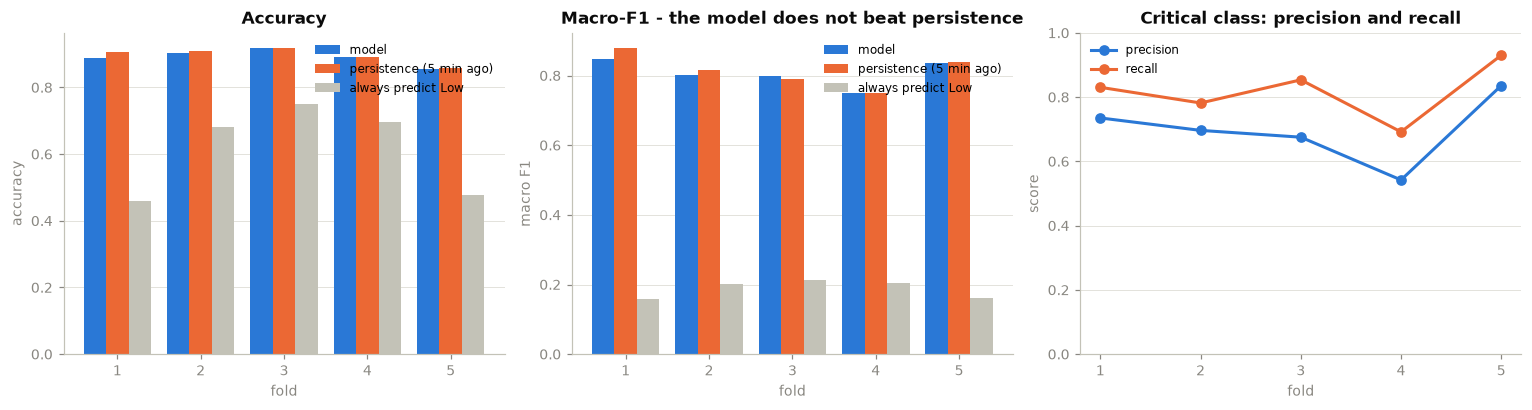

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
x = summary.fold.to_numpy()
width = 0.27

axes[0].bar(x - width, summary.accuracy, width, color=BLUE, label="model")
axes[0].bar(x, summary.persist_accuracy, width, color=ORANGE,
            label="persistence (5 min ago)")
axes[0].bar(x + width, summary.naive_accuracy, width, color=GREY,
            label="always predict Low")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("fold"); axes[0].set_ylabel("accuracy")
axes[0].set_xticks(x); axes[0].legend(fontsize=8); axes[0].grid(True, axis="y")

axes[1].bar(x - width, summary.macro_F1, width, color=BLUE, label="model")
axes[1].bar(x, summary.persist_macro_F1, width, color=ORANGE,
            label="persistence (5 min ago)")
axes[1].bar(x + width, summary.naive_macro_F1, width, color=GREY,
            label="always predict Low")
axes[1].set_title("Macro-F1 - the model does not beat persistence")
axes[1].set_xlabel("fold"); axes[1].set_ylabel("macro F1")
axes[1].set_xticks(x); axes[1].legend(fontsize=8); axes[1].grid(True, axis="y")

axes[2].plot(x, summary.critical_precision, marker="o", color=BLUE,
             linewidth=2, label="precision")
axes[2].plot(x, summary.critical_recall, marker="o", color=ORANGE,
             linewidth=2, label="recall")
axes[2].set_title("Critical class: precision and recall")
axes[2].set_xlabel("fold"); axes[2].set_ylabel("score")
axes[2].set_xticks(x); axes[2].set_ylim(0, 1); axes[2].legend(fontsize=8)
axes[2].grid(True, axis="y")

plt.tight_layout()
plt.show()

## Step 8 — What this baseline actually shows

### The good news

Against the naive baseline the model looks strong: macro-F1 around **0.75–0.85**
versus **0.16–0.21** for always answering "Low". The confusion matrices are also
healthy — nearly all mistakes land on an *adjacent* class (Low↔Medium,
High↔Critical) rather than jumping from Low to Critical. For an ordered scale that
is exactly the error pattern you want, and it suggests the model has learned the
ordering rather than memorising labels.

The class weighting worked as intended: Critical recall runs **0.69–0.93**, so the
model is not ignoring the rare class the way an unweighted fit would.

### The result that matters

**The model does not beat persistence.** Predicting "whatever this link was doing
five minutes ago" scores *better* on macro-F1 on folds 1, 2 and 5, and ties on
folds 3 and 4.

This is not a bug, and nothing in the pipeline is broken — the exclusion of
`utilization_pct` is correct, the folds are clean, and the model behaves sensibly.
It is a statement about **the task as currently framed**.

The reason is straightforward: we are predicting the congestion class at time *t*
using data up to *t − 5 minutes*, and link utilisation at 5-minute granularity
barely moves in five minutes. So the label is very nearly determined by `lag_1`,
and a model that adds hour-of-day, rolling statistics and link identity on top of
that has almost nothing left to explain.

**This is nowcasting, not forecasting.** For the adaptive-routing half of this
project, a prediction that arrives five minutes ahead of a change you could have
guessed by looking at the last reading is not useful — by the time you reroute,
the congestion is already there.

### What follows from this (not done here)

The natural next step is to **push the prediction horizon out** — predict the class
at *t + 15* or *t + 30* minutes from data up to *t*. Persistence degrades quickly
at those horizons, which is exactly where a model can earn its place. That is a
change to the problem definition, not a tuning exercise, so it belongs in its own
step rather than being patched in here.

Two smaller observations worth carrying forward:

- **Fold 4 is the weakest**, as notebook 04 predicted: macro-F1 **0.750**, Critical
  precision **0.542** — the lowest of any fold. With only 2,148 Critical rows in
  test and a model tuned by weights toward a 5% base rate, it over-predicts
  Critical and precision suffers.
- **Fold 5 was predicted to be hardest — and that was only half right.** It has the
  *lowest accuracy* (0.856) but the *best Critical scores* of any fold (precision
  0.836, recall 0.930, F1 0.881). The September episode produces sustained, clearly
  congested periods that are easy to identify; what drags accuracy down is the
  larger share of High and Critical rows, which are harder classes in general.
  Prediction half-right, and worth correcting explicitly.

In [11]:
summary.to_csv(PROCESSED / "baseline_fold_scores.csv", index=False)
per_class.to_csv(PROCESSED / "baseline_per_class_scores.csv", index=False)
print("saved baseline_fold_scores.csv and baseline_per_class_scores.csv")

saved baseline_fold_scores.csv and baseline_per_class_scores.csv
